In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir()

['.config', 'sample_data']

In [ ]:
%cd "/content/drive/My Drive/kaggle_rsna_problem"

[Errno 2] No such file or directory: '/content/drive/My Drive/kaggle_rsna_problem'
/content


In [ ]:
os.listdir()

['kaggle_evaluation', 'dataset']

In [ ]:
%cd "dataset"
os.listdir()

/content/drive/My Drive/kaggle_rsna_problem/dataset


['rsna-intracranial-aneurysm-detection.zip',
 'rsna-intracranial-aneurysm-detection',
 'series_list.txt',
 'progress.txt']

In [ ]:
!unzip -q rsna-intracranial-aneurysm-detection.zip -d rsna-intracranial-aneurysm-detection/

In [ ]:
# # About the dataset from kaggle
# kaggle_rsna_problem/
# │
# ├── train.csv
# ├── train_localizers.csv
# ├── series/                  ← contains DICOM folders per series ID
# ├── segmentations/          ← contains NIfTI vessel segmentations
# └── kaggle_evaluation/      ← inference & evaluation files (set aside for now)


In [ ]:
# visualizing the dicom and segmenations

In [ ]:
import pandas as pd
df_train=pd.read_csv('train.csv')

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 10.7 MB/s eta 0:00:00


DICOM Metadata:
  SpecificCharacterSet: ISO_IR 100
  ImageType: ['ORIGINAL', 'PRIMARY', 'M', 'ND', 'NORM']
  SOPClassUID: 1.2.840.10008.5.1.4.1.1.4
  SOPInstanceUID: 1.2.826.0.1.3680043.8.498.10124807242473374136099471315028464450
  StudyDate: 20230531
  SeriesDate: 20230531
  AcquisitionDate: 20230531
  ContentDate: 20230531
  StudyTime: 221059.706000
  SeriesTime: 223935.081000
  AcquisitionTime: 223303.237500
  ContentTime: 223936.601000
  AccessionNumber: 87
  Modality: MR
  Manufacturer: SIEMENS
  StudyDescription: MRA BRAIN
  SeriesDescription: AX COW
  ManufacturerModelName: Aera
  PatientName: 76dc135c-f3d
  PatientID: 76dc135c-f3d
  PatientSex: F
  PatientAge: 065Y
  PatientSize: 1.676
  PatientWeight: 71.6
  EthnicGroup: Not Hispanic/Lat
  SmokingStatus: UNKNOWN
  PatientIdentityRemoved: YES
  DeidentificationMethod: RSNA DICOM ANONYMIZER;RSNA-DDF
  DeidentificationMethodCodeSequence: [(0008,0100) Code Value                          SH: '113100'
(0008,0102) Coding Scheme Desi

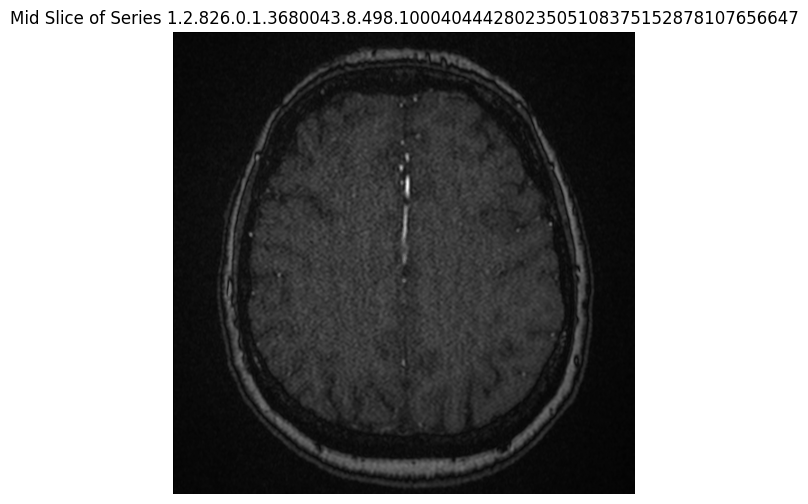

In [ ]:
# pydicom.dcmread returns a FileDataset object, which represents the parsed DICOM file. This object contains the data elements of the DICOM file, including the `metadata` and, optionally, the `pixel data`, depending on how the file was read.
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import os

def extract_and_print_metadata(dicom_file):
    """
    Extracts and prints metadata from a pydicom FileDataset object.
    """
    print("DICOM Metadata:")
    for data_element in dicom_file:
        if data_element.keyword:
            print(f"  {data_element.keyword}: {data_element.value}")
# 1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647
def load_dicom_series(series_path):
    """
      Dicom loading function from a scan series
      input: The series folder path by id
      output: A numpy array of the images
    """
    files = [pydicom.dcmread(os.path.join(series_path, f)) for f in sorted(os.listdir(series_path))]
    images = np.stack([f.pixel_array for f in files])
    # metadata
    if files: # Check if there are files before trying to access the first one
        extract_and_print_metadata(files[0])
    return images

# Visualize a sample
# Need to load df_train first to get a series_id with an aneurysm
series_id = "1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647"
img3d = load_dicom_series(os.path.join('dataset/rsna-intracranial-aneurysm-detection/series/', series_id))

plt.figure(figsize=(6,6))
print(f"Shape {img3d.shape}")
plt.imshow(img3d[img3d.shape[0]//2], cmap='gray')
plt.title(f'Mid Slice of Series {series_id}')
plt.axis('off')
plt.show()

In [ ]:
img_slice=pydicom.dcmread(os.path.join('dataset/rsna-intracranial-aneurysm-detection/series/1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647/1.2.826.0.1.3680043.8.498.10124807242473374136099471315028464450.dcm'))
img=img_slice.pixel_array
print(img.shape)
print(np.max(img))
print(np.min(img))

(512, 512)
400
0


In [ ]:
os.listdir()

['rsna-intracranial-aneurysm-detection.zip',
 'rsna-intracranial-aneurysm-detection',
 'series_list.txt']

In [ ]:
# %cd 'rsna-intracranial-aneurysm-detection/segmentations'
len(os.listdir())

178

In [ ]:
# len(set(os.listdir()))

178

In [ ]:
# Some series id may not have segmentations
seg_id = '1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381'
cow_seg_path=os.path.join(f'./{seg_id}', f'{seg_id}_cowseg.nii')
cow_seg_img = nib.load(cow_seg_path)
cow_seg_data = cow_seg_img.get_fdata()
print(f"====Channel-No = {187}===")
print(f"Unique Values: {np.unique(cow_seg_data[:,:,187])}")

Segmentation shape: (1024, 1024, 136)
COW Segmentation shape: (1024, 1024, 136)


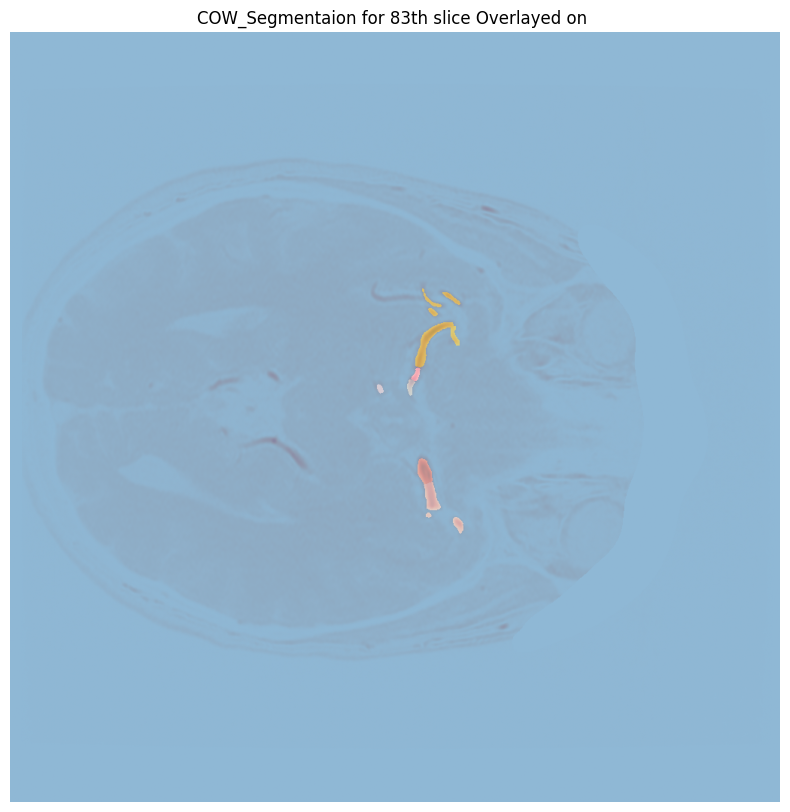

In [ ]:
# /content/drive/MyDrive/kaggle_rsna_problem/dataset/rsna-intracranial-aneurysm-detection/segmentations/1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485

import nibabel as nib
import os
import matplotlib.pyplot as plt
import numpy as np
# Some series id may not have segmentations
seg_id = '1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485'
seg_path = os.path.join(f'./{seg_id}', f'{seg_id}.nii')

cow_seg_path=os.path.join(f'./{seg_id}', f'{seg_id}_cowseg.nii')

def show_cow_seg_on_img(seg_path,cow_seg_path,channel=114):

    """
        Visualize the segmenation data.
        Note: 0 means background and rest 1-13 represent-
        Label Value | Label
        1-	Other Posterior Circulation
        2-	Basilar Tip
        3-	Right Posterior Communicating Artery
        4-	Left Posterior Communicating Artery
        5-	Right Infraclinoid Internal Carotid Artery
        6-	Left Infraclinoid Internal Carotid Artery
        7-	Right Supraclinoid Internal Carotid Artery
        8-	Left Supraclinoid Internal Carotid Artery
        9-	Right Middle Cerebral Artery
        10-	Left Middle Cerebral Artery
        11-	Right Anterior Cerebral Artery
        12-	Left Anterior Cerebral Artery
        13-	Anterior Communicating Artery
    """
    # print(os.listdir('samples/segmentations'))
    if os.path.exists(seg_path):
        seg_img = nib.load(seg_path)
        seg_data = seg_img.get_fdata()

        cow_seg_img = nib.load(cow_seg_path)
        cow_seg_data = cow_seg_img.get_fdata()

        ## Loop for checking relevant slices which contain anuerysm presence
        # for i in range(seg_data.shape[2]):
        #     print(f"====Slice-No = {i}===")
        #     print(f"Unique Values: {np.unique(seg_data[:,:,i])}")

        print("Segmentation shape:", seg_data.shape)
        print("COW Segmentation shape:", cow_seg_data.shape)
        # print(np.unique(seg_data))

        plt.figure(figsize=(10,10))
        plt.imshow(seg_data[:,:,channel],alpha=0.5, cmap='Reds')
        plt.imshow(cow_seg_data[:,:,channel], alpha=0.5, cmap='tab20')
        plt.title(f"COW_Segmentaion for {channel}th slice Overlayed on ")
        plt.axis('off')
        plt.show()
    else:
        print("No segmentation available for this series.")
show_cow_seg_on_img(seg_path=seg_path,cow_seg_path=cow_seg_path,channel=83)


In [ ]:
os.getcwd()

'/content/drive/MyDrive/kaggle_rsna_problem'

In [ ]:
%cd '../../../'
%ls

/content/drive/MyDrive/kaggle_rsna_problem
dataset/  kaggle_evaluation/


In [ ]:
%cd 'kaggle_rsna_problem'
%ls

/content/drive/MyDrive/kaggle_rsna_problem
dataset/  kaggle_evaluation/


In [ ]:
import os
os.getcwd()

'/content/drive/MyDrive/kaggle_rsna_problem'

In [ ]:
import zipfile
import os

n_batches=20
for i in range(n_batches):
  # Paths
  zip_path = "dataset/rsna-intracranial-aneurysm-detection.zip"
  output_dir = "dataset/rsna-intracranial-aneurysm-detection"
  progress_file = "dataset/progress.txt"

  batch_size = 5 # number of series folders per batch

  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
      # All files inside series/
      series_files = [f for f in zip_ref.namelist() if f.startswith("series/")]
      # Unique series IDs
      series_ids = sorted(list({f.split("/")[1] for f in series_files if "/" in f}))

      print(f"Total series folders: {len(series_ids)}")

      # Load progress
      if os.path.exists(progress_file):
          with open(progress_file, "r") as f:
              start_batch = int(f.read().strip())
      else:
          start_batch = 0

      print(f"Starting from batch {start_batch + 1}")

      # Extract only the next batch
      if start_batch * batch_size >= len(series_ids):
          print("✅ All batches already extracted!")
      else:
          batch_ids = series_ids[start_batch * batch_size : (start_batch + 1) * batch_size]
          print(f"Extracting batch {start_batch + 1} ({len(batch_ids)} folders)...")

          for sid in batch_ids:
              sid_files = [f for f in series_files if f.startswith(f"series/{sid}/")]
              zip_ref.extractall(output_dir, members=sid_files)
              print(f"✅ Extracted {len(sid_files)} files for series {sid}")

          print(f"✅ Finished batch {start_batch + 1}")

          # Save progress for next run
          with open(progress_file, "w") as f:
              f.write(str(start_batch + 1))

          print("\n⏸️ Paused — You can process this batch now.")
          print("▶ Run the script again to extract the next batch.")


Total series folders: 4405
Starting from batch 489
Extracting batch 489 (5 folders)...
✅ Extracted 84 files for series 1.2.826.0.1.3680043.8.498.46183977217172321492490042401326563260
✅ Extracted 368 files for series 1.2.826.0.1.3680043.8.498.46220103272693308023432315673825922654
✅ Extracted 175 files for series 1.2.826.0.1.3680043.8.498.46243061759276657725858453251302198588
✅ Extracted 24 files for series 1.2.826.0.1.3680043.8.498.46258470630691096509479948523824866971
✅ Extracted 37 files for series 1.2.826.0.1.3680043.8.498.46291251820907849873202645861588937407
✅ Finished batch 489

⏸️ Paused — You can process this batch now.
▶ Run the script again to extract the next batch.
Total series folders: 4405
Starting from batch 490
Extracting batch 490 (5 folders)...
✅ Extracted 824 files for series 1.2.826.0.1.3680043.8.498.46310330137045631742117287057102724959
✅ Extracted 19 files for series 1.2.826.0.1.3680043.8.498.46323212394021990293051146253964627947
✅ Extracted 570 files for se

In [ ]:
# The below code is just for checking out metadata present in test data

In [ ]:
import os
os.listdir()

['kaggle_evaluation',
 'dataset',
 'artifacts',
 'train_localizers.csv',
 'train.csv']

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 10.9 MB/s eta 0:00:00


In [ ]:
len(set(os.listdir('dataset/rsna-intracranial-aneurysm-detection/series')))

4405

In [ ]:
"""
  Checking common metadata tags in test and train data
"""
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import os

def extract_metadata(dicom_file):
    """
    Extracts and prints metadata from a pydicom FileDataset object.
    """
    lst=[]
    for data_element in dicom_file:
        if data_element.keyword:
          lst.append(data_element.keyword)
    return lst
# 1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647
def load_dicom_series_from_metadata(series_path):
    """
      Dicom loading function from a scan series
      input: The series folder path by id
      output: A metadata list
    """
    for file in sorted(os.listdir(series_path)):
      lst=extract_metadata(pydicom.dcmread(os.path.join(series_path, file)))
      return lst

# example
series_id_train = "1.2.826.0.1.3680043.8.498.97856025906265309755009045740425954643"
meta_train=load_dicom_series_from_metadata(os.path.join('dataset/rsna-intracranial-aneurysm-detection/series/', series_id_train))

series_id_test = "1.2.826.0.1.3680043.8.498.10028406715369553772267826812576760572"
meta_test=load_dicom_series_from_metadata(os.path.join('kaggle_evaluation/series', series_id_test))

# extract common tags
print('Common Tags')
for tag in meta_test:
  if(tag in meta_train):
    print(tag)

Common Tags
SOPClassUID
SOPInstanceUID
Modality
PatientID
SliceThickness
StudyInstanceUID
SeriesInstanceUID
InstanceNumber
ImagePositionPatient
ImageOrientationPatient
FrameOfReferenceUID
SamplesPerPixel
PhotometricInterpretation
Rows
Columns
PixelSpacing
BitsAllocated
BitsStored
HighBit
PixelRepresentation
PixelData


In [ ]:
"""
  Checking common metadata tags in test and train data
"""
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import os

def extract_metadata(dicom_file):
    """
    Extracts and prints metadata from a pydicom FileDataset object.
    """
    lst=[]
    for data_element in dicom_file:
        if data_element.keyword:
          lst.append(data_element.keyword)
    return lst
# 1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647
def load_dicom_series_from_metadata(series_path):
    """
      Dicom loading function from a scan series
      input: The series folder path by id
      output: A metadata list
    """
    for file in sorted(os.listdir(series_path)):
      lst=extract_metadata(pydicom.dcmread(os.path.join(series_path, file)))
      return lst

# example
series_id_train = "1.2.826.0.1.3680043.8.498.97856025906265309755009045740425954643"
series_path_train = os.path.join('dataset/rsna-intracranial-aneurysm-detection/series/', series_id_train)
meta_train=load_dicom_series_from_metadata(series_path_train)

series_id_test = "1.2.826.0.1.3680043.8.498.10028406715369553772267826812576760572"
series_path_test = os.path.join('kaggle_evaluation/series', series_id_test)
meta_test=load_dicom_series_from_metadata(series_path_test)

# extract common tags
common_tags = [tag for tag in meta_test if tag in meta_train]
print('Common Tags and their values (from test series):')
# Load a sample DICOM file from the test series to get values
sample_dcm_file_test = pydicom.dcmread(os.path.join(series_path_test, sorted(os.listdir(series_path_test))[0]))

for tag in common_tags:
  try:
    print(f"  {tag}: {getattr(sample_dcm_file_test, tag)}")
  except AttributeError:
    print(f"  {tag}: Value not available in sample file")

print('Common Tags and their values (from train series):')
# Load a sample DICOM file from the test series to get values
sample_dcm_file_test = pydicom.dcmread(os.path.join(series_path_train, sorted(os.listdir(series_path_train))[0]))

for tag in common_tags:
  try:
    print(f"  {tag}: {getattr(sample_dcm_file_test, tag)}")
  except AttributeError:
    print(f"  {tag}: Value not available in sample file")

Common Tags and their values (from test series):
  SOPClassUID: 1.2.840.10008.5.1.4.1.1.4
  SOPInstanceUID: 1.2.826.0.1.3680043.8.498.10086425055396889038257927884122962676
  Modality: MR
  PatientID: 2d7056cd-a66
  SliceThickness: 1
  StudyInstanceUID: 1.2.826.0.1.3680043.8.498.92036735550297900604720522165601531201
  SeriesInstanceUID: 1.2.826.0.1.3680043.8.498.10028406715369553772267826812576760572
  InstanceNumber: 113
  ImagePositionPatient: [-115.01414203644, -137.79509544372, 6.2931770571509]
  ImageOrientationPatient: [1, -6.123234e-017, 7.888609052e-031, 6.123233996e-017, 1, -7.10542736e-015]
  FrameOfReferenceUID: 1.2.826.0.1.3680043.8.498.11811620029624765973121972843116097787
  SamplesPerPixel: 1
  PhotometricInterpretation: MONOCHROME2
  Rows: 256
  Columns: 256
  PixelSpacing: [1, 1]
  BitsAllocated: 16
  BitsStored: 16
  HighBit: 15
  PixelRepresentation: 1
  PixelData: b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 16.4 MB/s eta 0:00:00


In [ ]:
"""
  Checking for range of intensity values in pydicom files
  and performing basic preprocessing for inspection.
"""
import pydicom as dcm
import matplotlib.pyplot as plt
import cv2
import numpy as np

def show_preprocess(dicom_image_path, preprocess_size, normalize=False):
    """
    Function to test preprocessor on DICOM images.
    Shows histograms + images side by side.
    """
    # Extract image
    img = dcm.dcmread(dicom_image_path)
    img_array = img.pixel_array

    # Flatten original
    flattened_img = img_array.flatten()

    print("Original Image size")
    print(f"  ➤ Height : {img_array.shape[0]}")
    print(f"  ➤ Width : {img_array.shape[1]}")

    print("Original Image intensity information")
    print(f"  ➤ Minimum intensity : {np.min(flattened_img)}")
    print(f"  ➤ Maximum intensity : {np.max(flattened_img)}")

    # Preprocess (resize)
    preprocessed_image = cv2.resize(
        img_array,
        (preprocess_size, preprocess_size),
        interpolation=cv2.INTER_CUBIC
    )
    flattened_img_p = preprocessed_image.flatten()
    print("\nPreprocessed Image intensity information")
    print(f"  ➤ Minimum intensity : {np.min(flattened_img_p)}")
    print(f"  ➤ Maximum Intensity : {np.max(flattened_img_p)}")

    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"Preprocessing Visualization (Modality: {img.Modality})", fontsize=16, fontweight="bold")

    # Histogram - original
    axes[0, 0].hist(flattened_img, bins=50, color="steelblue", edgecolor="black")
    axes[0, 0].set_title("Histogram (Original Image)")
    axes[0, 0].set_xlabel("Pixel Value")
    axes[0, 0].set_ylabel("Frequency")

    # Show original image
    axes[0, 1].imshow(img_array, cmap="gray")
    axes[0, 1].set_title("Original Image")
    axes[0, 1].axis("off")

    # Histogram - preprocessed
    axes[1, 0].hist(flattened_img_p, bins=50, color="seagreen", edgecolor="black")
    axes[1, 0].set_title("Histogram (Preprocessed Image)")
    axes[1, 0].set_xlabel("Pixel Value")
    axes[1, 0].set_ylabel("Frequency")

    # Show preprocessed image
    axes[1, 1].imshow(preprocessed_image, cmap="gray")
    axes[1, 1].set_title("Preprocessed Image")
    axes[1, 1].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


In [ ]:
series_folder_path='dataset/rsna-intracranial-aneurysm-detection/series'

Original Image size
  ➤ Height : 512
  ➤ Width : 512
Original Image intensity information
  ➤ Minimum intensity : 0
  ➤ Maximum intensity : 485

Preprocessed Image intensity information
  ➤ Minimum intensity : -10
  ➤ Maximum Intensity : 481


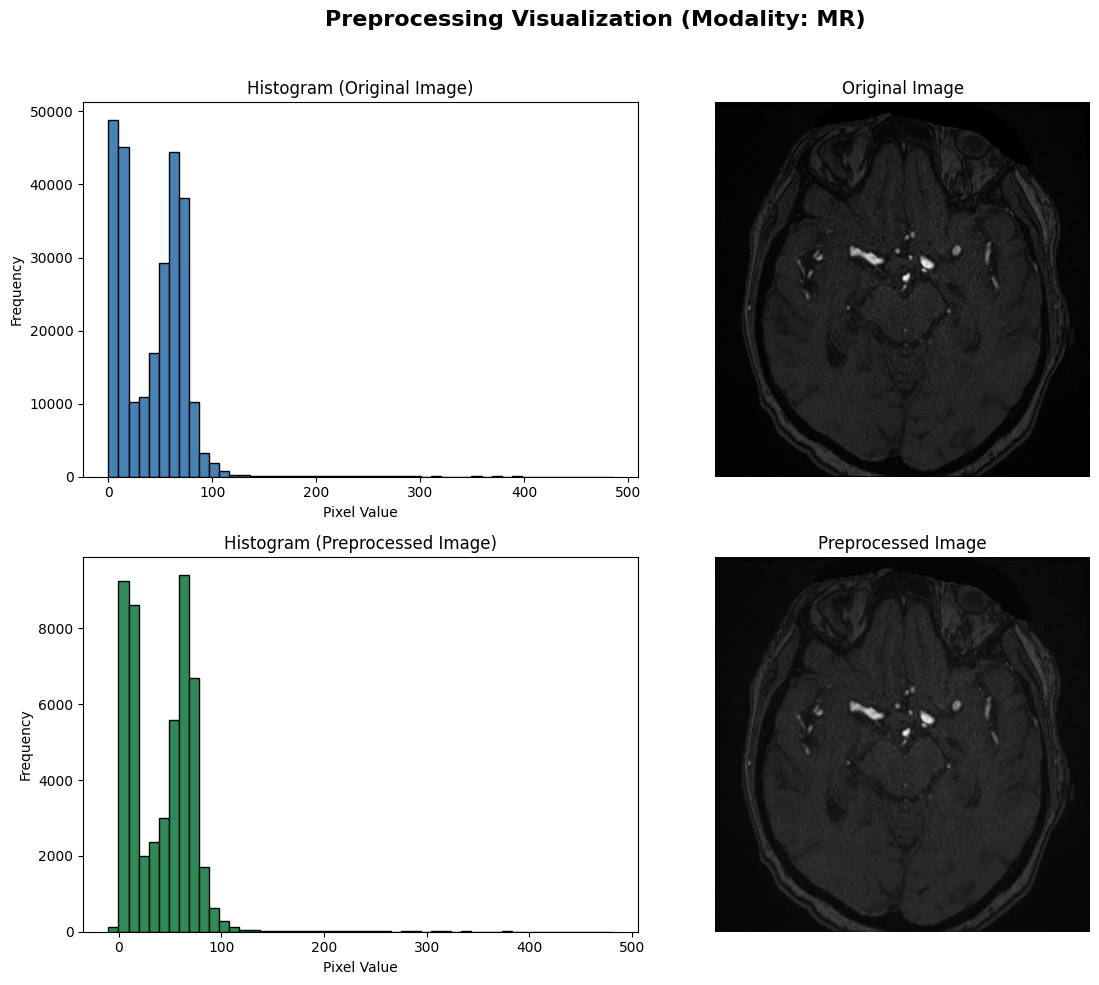

In [ ]:
# mra
dcm_file_path=os.path.join(series_folder_path,'1.2.826.0.1.3680043.8.498.10023411164590664678534044036963716636/1.2.826.0.1.3680043.8.498.24186535344744886473554579401056227253.dcm')

show_preprocess(dicom_image_path=dcm_file_path,preprocess_size=224,normalize=False)

Original Image size
  ➤ Height : 512
  ➤ Width : 512
Original Image intensity information
  ➤ Minimum intensity : -1024
  ➤ Maximum intensity : 1709

Preprocessed Image intensity information
  ➤ Minimum intensity : -1025
  ➤ Maximum Intensity : 1703


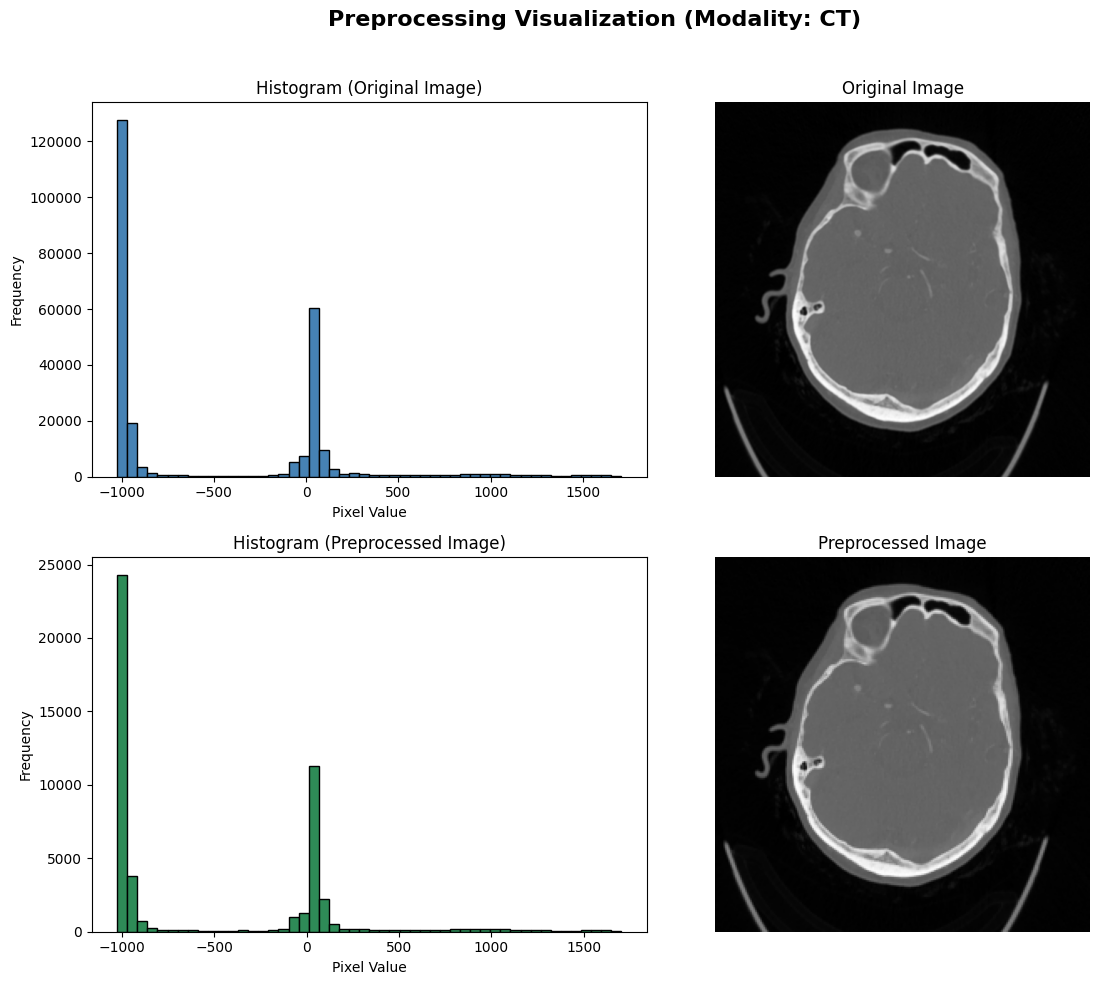

In [ ]:
# cta
dcm_file_path=os.path.join(series_folder_path,'1.2.826.0.1.3680043.8.498.10022796280698534221758473208024838831/1.2.826.0.1.3680043.8.498.53868409774237283281776807176852774246.dcm')

show_preprocess(dicom_image_path=dcm_file_path,preprocess_size=224,normalize=False)

Original Image size
  ➤ Height : 512
  ➤ Width : 512
Original Image intensity information
  ➤ Minimum intensity : 0
  ➤ Maximum intensity : 1286

Preprocessed Image intensity information
  ➤ Minimum intensity : -116
  ➤ Maximum Intensity : 1252


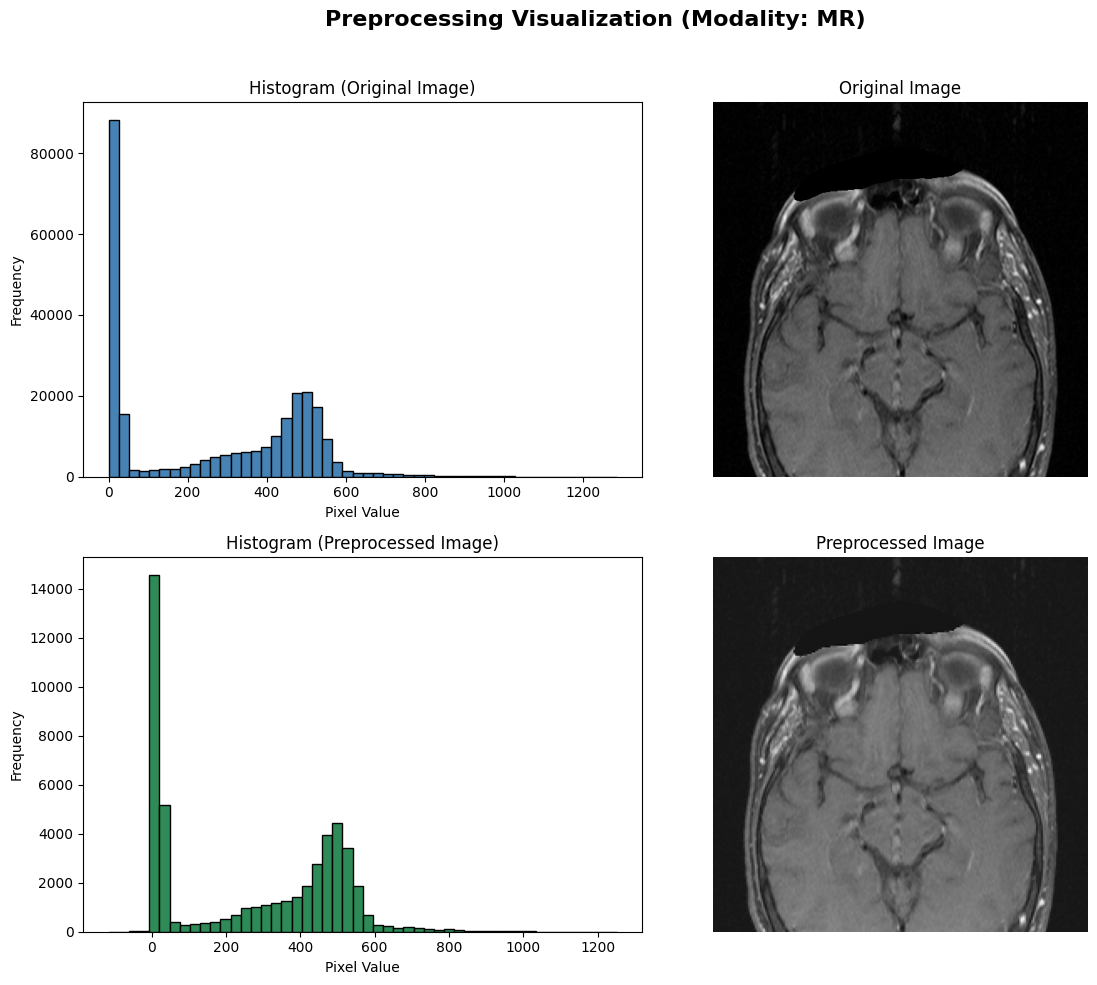

In [ ]:
# mri -t1 post
dcm_file_path=os.path.join(series_folder_path,'1.2.826.0.1.3680043.8.498.10098743283291956051221530305664415374/1.2.826.0.1.3680043.8.498.71587504819983455216441686559923000438.dcm')

show_preprocess(dicom_image_path=dcm_file_path,preprocess_size=224,normalize=False)

Original Image size
  ➤ Height : 512
  ➤ Width : 512
Original Image intensity information
  ➤ Minimum intensity : 0
  ➤ Maximum intensity : 2121

Preprocessed Image intensity information
  ➤ Minimum intensity : -195
  ➤ Maximum Intensity : 2097


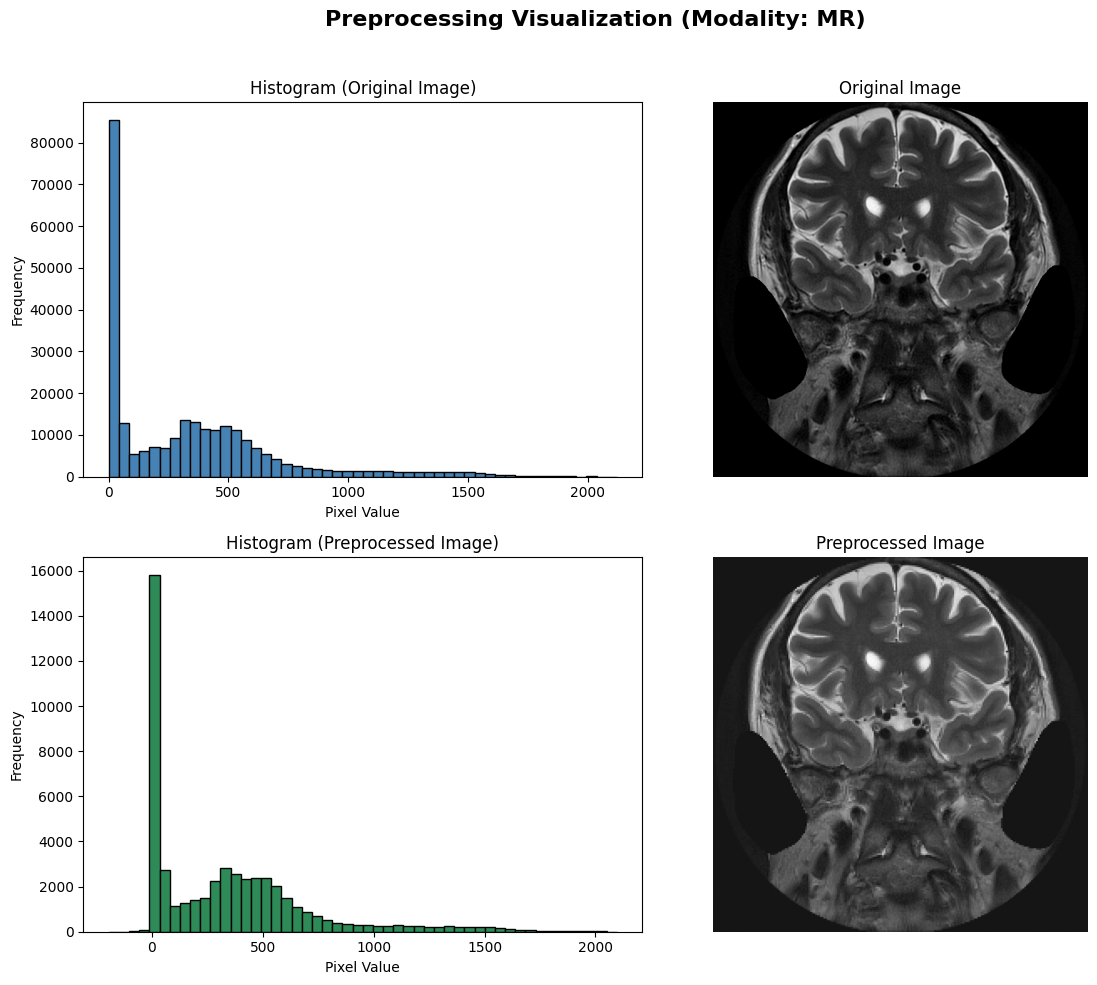

In [ ]:
# mri T2
dcm_file_path=os.path.join(series_folder_path,'1.2.826.0.1.3680043.8.498.10116626135148932224643146695383345963/1.2.826.0.1.3680043.8.498.76837443712461230984428728904305383754.dcm')

show_preprocess(dicom_image_path=dcm_file_path,preprocess_size=224,normalize=False)

Original Image size
  ➤ Height : 512
  ➤ Width : 512
Original Image intensity information
  ➤ Minimum intensity : 0
  ➤ Maximum intensity : 485

Preprocessed Image intensity information
  ➤ Minimum intensity : -10
  ➤ Maximum Intensity : 462


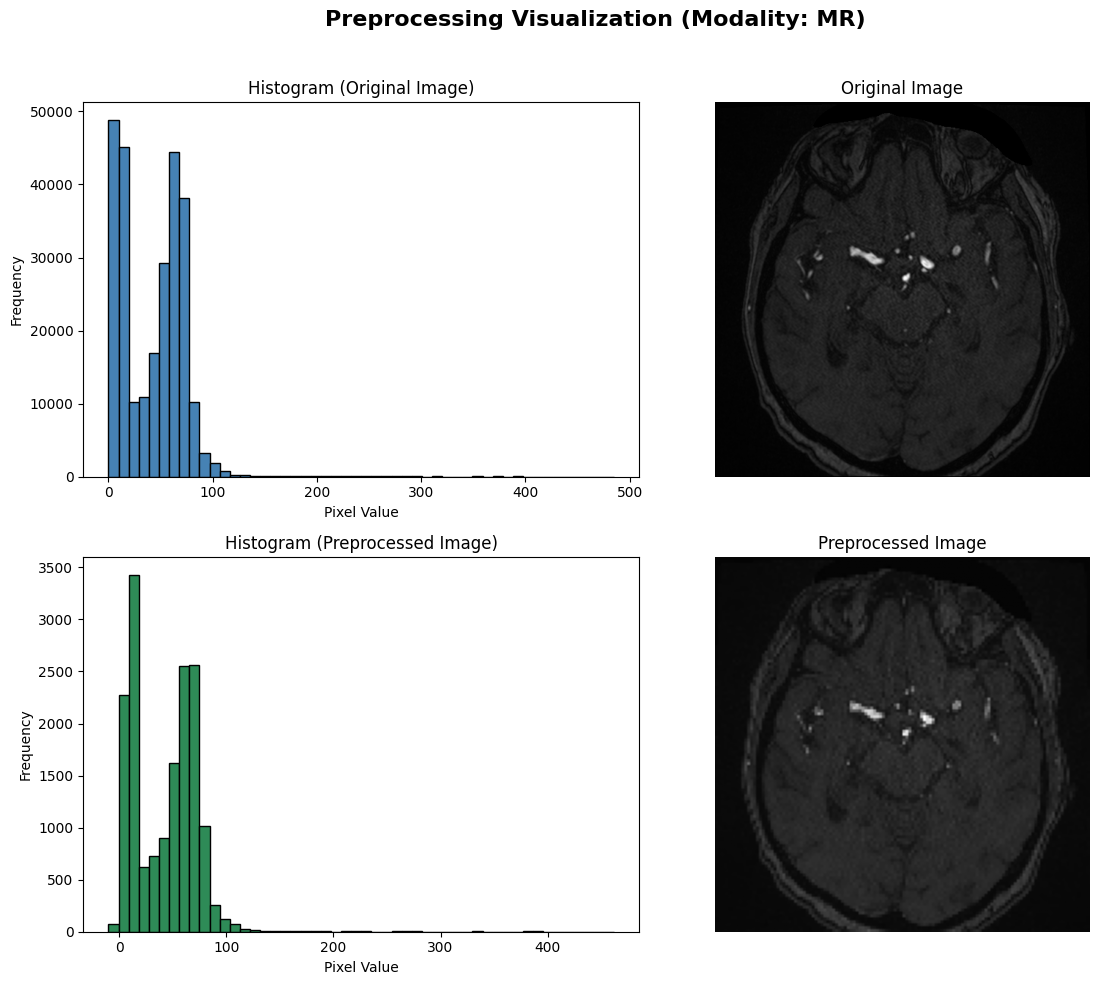

In [ ]:
# mra- size 128
dcm_file_path=os.path.join(series_folder_path,'1.2.826.0.1.3680043.8.498.10023411164590664678534044036963716636/1.2.826.0.1.3680043.8.498.24186535344744886473554579401056227253.dcm')

show_preprocess(dicom_image_path=dcm_file_path,preprocess_size=128,normalize=False)

Original Image size
  ➤ Height : 512
  ➤ Width : 512
Original Image intensity information
  ➤ Minimum intensity : -1024
  ➤ Maximum intensity : 1709

Preprocessed Image intensity information
  ➤ Minimum intensity : -1025
  ➤ Maximum Intensity : 1724


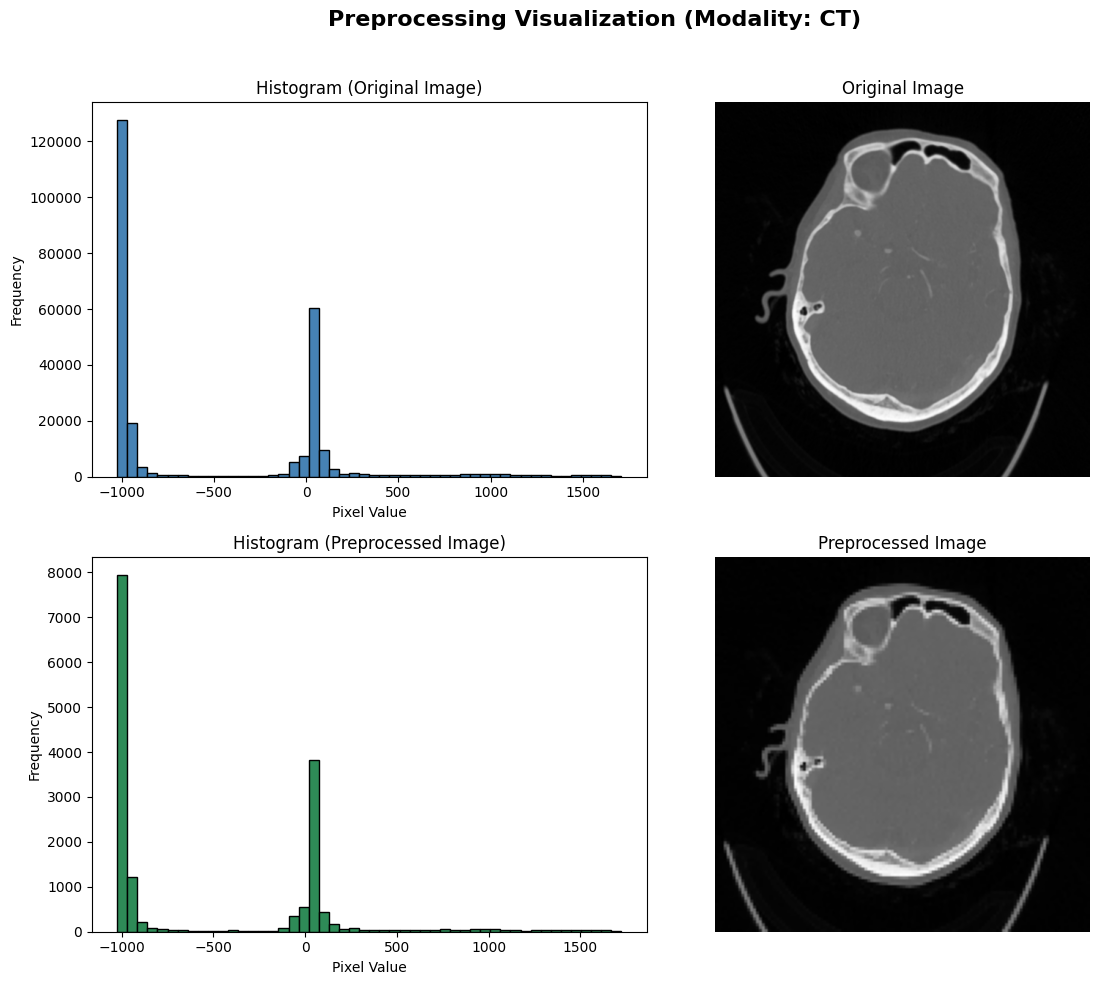

In [ ]:
# cta- size 128
dcm_file_path=os.path.join(series_folder_path,'1.2.826.0.1.3680043.8.498.10022796280698534221758473208024838831/1.2.826.0.1.3680043.8.498.53868409774237283281776807176852774246.dcm')

show_preprocess(dicom_image_path=dcm_file_path,preprocess_size=128,normalize=False)

In [ ]:
# 🤔What are the typical distribution of channels of dicom files so that we can use a padding or capping while feeding vector embeddings into transformer

import os
import matplotlib.pyplot as plt

# Calculate number of slices (channels) per series
lst = [
    len(os.listdir(os.path.join(series_folder_path, series)))
    for series in os.listdir(series_folder_path)
]



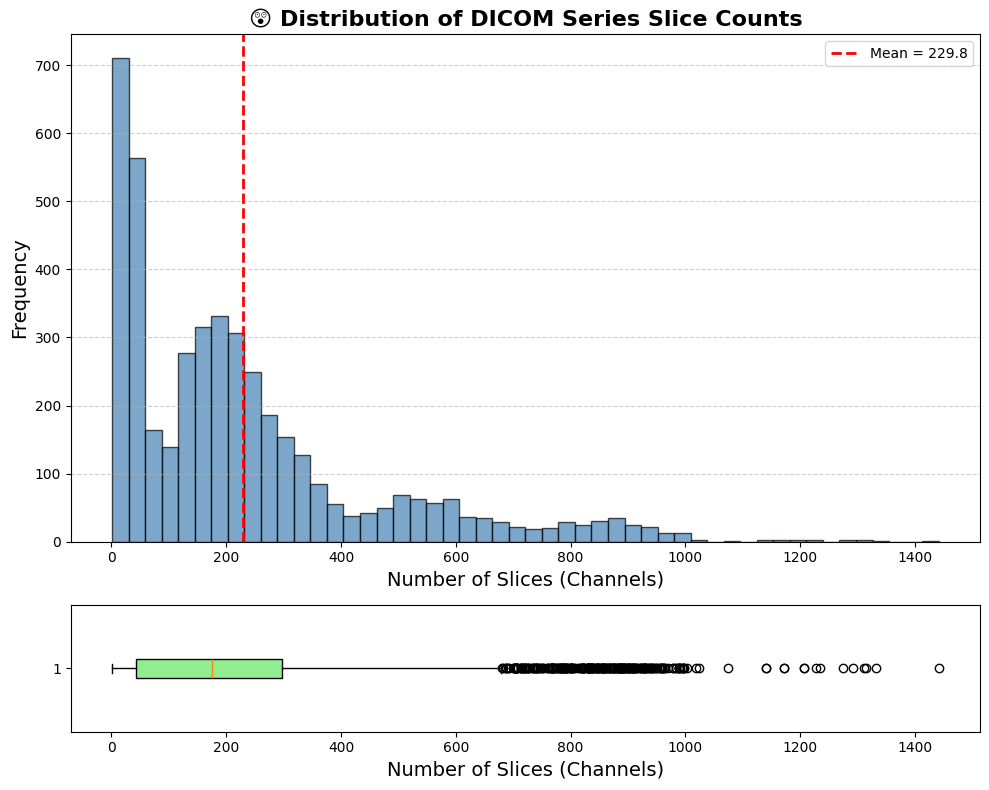

In [ ]:
import matplotlib.pyplot as plt

# Histogram + Boxplot
fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [4, 1]})

# Histogram
axes[0].hist(lst, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_title("😲 Distribution of DICOM Series Slice Counts", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Number of Slices (Channels)", fontsize=14)
axes[0].set_ylabel("Frequency", fontsize=14)
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# Mean line
mean_val = sum(lst) / len(lst)
axes[0].axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_val:.1f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(lst, vert=False, patch_artist=True, boxprops=dict(facecolor="lightgreen", color="black"))
axes[1].set_xlabel("Number of Slices (Channels)", fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

cap = int(np.percentile(lst, 95))
print("Recommended cap (95th percentile):", cap)


Recommended cap (95th percentile): 759


In [ ]:
import numpy as np
print(f'Max number of channels present per slice: {np.max(lst)}')

Max number of channels present per slice: 1441


# Train Test split

In [ ]:
# sorted accordin to z index
train_csv_save_path='/content/drive/MyDrive/kaggle_rsna_problem/artifacts/preprocessor/preprocessor_aprroach_1/data/train_z.csv'   # train_z.csv path
test_csv_save_path='/content/drive/MyDrive/kaggle_rsna_problem/artifacts/preprocessor/preprocessor_aprroach_1/data/test_z.csv'   # test_z.csv path

# read path
train_csv_read_path='/content/drive/MyDrive/kaggle_rsna_problem/dataset/rsna-intracranial-aneurysm-detection/data_csvs/train.csv'   # train_z.csv path

In [ ]:
import pandas as pd
all_train_df=pd.read_csv(train_csv_read_path)

In [ ]:
columns=all_train_df.columns

(array([0.95043511, 0.        , 0.        , 1.40522134, 0.        ,
        0.        , 0.74612183, 0.        , 0.        , 0.23155505]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

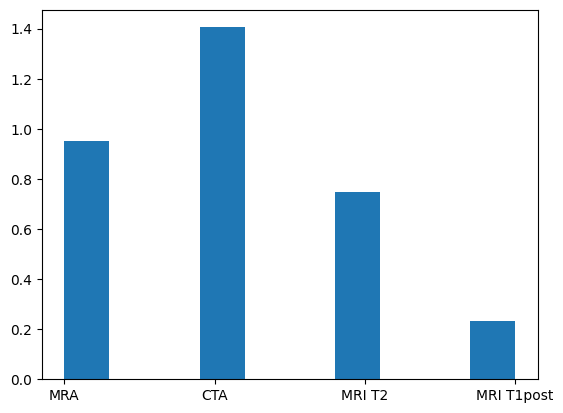

In [ ]:
import matplotlib.pyplot as plt
plt.hist(all_train_df['Modality'],density=True)

In [ ]:
# series processed via z index sorting
series_data='/content/drive/MyDrive/kaggle_rsna_problem/artifacts/preprocessor/preprocessor_aprroach_1/data/series'
import os
series=[os.path.splitext(os.path.basename(f))[0] for f in os.listdir(series_data) if os.path.splitext(os.path.basename(f))[1]=='.npy' ]

In [ ]:
print(f'➡️ Avalaible series scans : {len(series)}')

➡️ Avalaible series scans : 4081


In [ ]:
to_drop_indices=[]
for i,row in all_train_df.iterrows():
    if not(row['SeriesInstanceUID'] in series): to_drop_indices.append(i)

In [ ]:
len(to_drop_indices)

324

In [ ]:
all_train_df.drop(to_drop_indices,inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(all_train_df, test_size=0.1, random_state=42)

(array([1.5241467 , 0.        , 0.        , 0.89143065, 0.        ,
        0.        , 0.66630356, 0.        , 0.        , 0.25145243]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

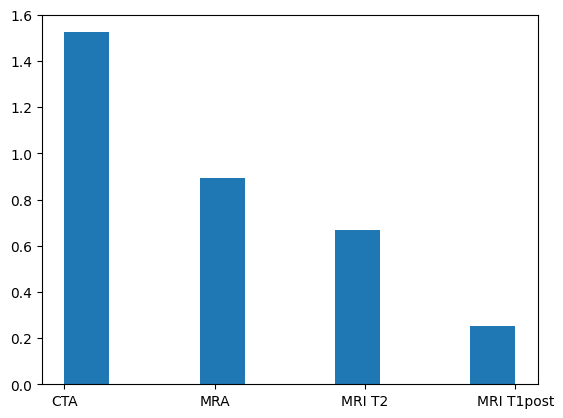

In [ ]:
# After splitting distribution of modalities
plt.hist(train_df['Modality'],density=True)

(array([1.45069275, 0.        , 0.        , 0.94539527, 0.        ,
        0.        , 0.23634882, 0.        , 0.        , 0.7008965 ]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

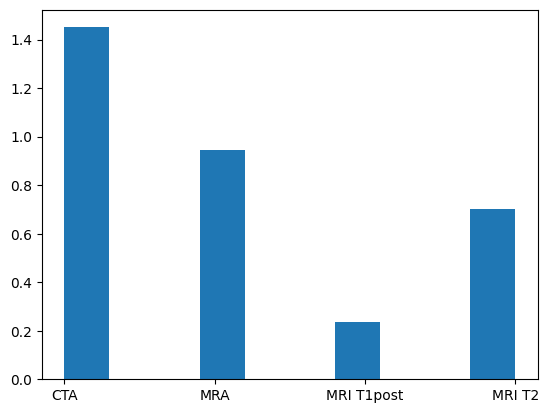

In [ ]:
plt.hist(test_df['Modality'],density=True)

In [ ]:
train_df.to_csv(train_csv_save_path,index=False)
test_df.to_csv(test_csv_save_path,index=False)